# Exercise 4.A Introduction to Linear Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [2]:
# Sample data: hours studied and exam scores
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score': [52, 55, 60, 65, 68, 72, 78, 82, 88, 93]
}

df = pd.DataFrame(data)

# Feature matrix and target variable
X = df[['hours_studied']]
y = df['exam_score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Working through the sample script

In [3]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.50
Intercept: 46.50


In [4]:
y_pred = model.predict(X_test)

print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [88, 55]
Predicted scores: [np.float64(87.0), np.float64(55.5)]


In [5]:
r_squared = model.score(X_test, y_test)

print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R² score tells me how well the linear regression model explains the relationship between hours studied and exam score. A score close to 1 means the model explains most of the variation in exam scores. In this case, the model appears to fit the data well because the predicted scores are close to the actual scores.

C:\Users\dimit\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


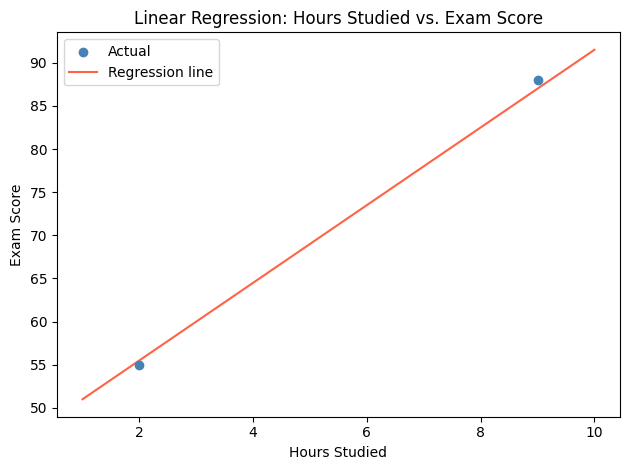

In [6]:
# Scatter plot: actual test data points
plt.scatter(
    X_test,
    y_test,
    color='steelblue',
    label='Actual',
    zorder=3
)

# Line: model predictions across the full range of X
x_range = np.linspace(
    X['hours_studied'].min(),
    X['hours_studied'].max(),
    100
).reshape(-1, 1)

y_line = model.predict(x_range)

plt.plot(
    x_range,
    y_line,
    color='tomato',
    label='Regression line'
)

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points appear close to the regression line, which means the model fits the data well visually. The line shows that as hours studied increases, the predicted exam score also increases. This matches the idea that there is a positive relationship between studying more and scoring higher.

## Lab 2
### Building your own model

In [7]:
ad_data = {
    'monthly_ad_spend': [
        500, 1000, 1500, 2000, 2500,
        3000, 3500, 4000, 4500, 5000,
        5500, 6000, 6500, 7000, 7500,
        8000, 8500, 9000, 9500, 10000
    ],
    'monthly_revenue': [
        4200, 5100, 6800, 7400, 8900,
        9200, 10500, 11800, 12400, 13100,
        14200, 15600, 15900, 17200, 18100,
        19400, 20200, 21500, 22100, 23800
    ]
}

df_ads = pd.DataFrame(ad_data)

df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [8]:
X2 = df_ads[['monthly_ad_spend']]
y2 = df_ads['monthly_revenue']

print("X2 shape:", X2.shape)
print("y2 shape:", y2.shape)

X2 shape: (20, 1)
y2 shape: (20,)


In [9]:
df_ads[['monthly_ad_spend']]

,monthly_ad_spend
0,500
1,1000
2,1500
3,2000
4,2500
5,3000
6,3500
7,4000
8,4500
9,5000


In [10]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42
)

print("X2_train shape:", X2_train.shape)
print("X2_test shape:", X2_test.shape)
print("y2_train shape:", y2_train.shape)
print("y2_test shape:", y2_test.shape)

X2_train shape: (16, 1)
X2_test shape: (4, 1)
y2_train shape: (16,)
y2_test shape: (4,)


In [11]:
model2 = LinearRegression()

model2.fit(X2_train, y2_train)

print("Model trained successfully.")

Model trained successfully.


In [12]:
print(f"Slope (coefficient): {model2.coef_[0]:.2f}")
print(f"Intercept: {model2.intercept_:.2f}")

# Interpretation:
# For each additional $1 spent on advertising,
# the predicted monthly revenue increases by about model2.coef_[0] dollars

Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [13]:
y2_pred = model2.predict(X2_test)

prediction_results = pd.DataFrame({
    'Actual Revenue': y2_test.values,
    'Predicted Revenue': y2_pred.round(2)
})

prediction_results

,Actual Revenue,Predicted Revenue
0,4200,4603.85
1,21500,21229.03
2,19400,19273.13
3,5100,5581.80


In [14]:
r2_model2 = model2.score(X2_test, y2_test)

print(f"R² score: {r2_model2:.3f}")

R² score: 0.998


The R² score is very close to 1, which means the model fits the data very well. This tells me that monthly ad spend explains most of the variation in monthly revenue. Based on this result, ad spend appears to be a strong predictor of revenue in this dataset.

### Visualizing the results

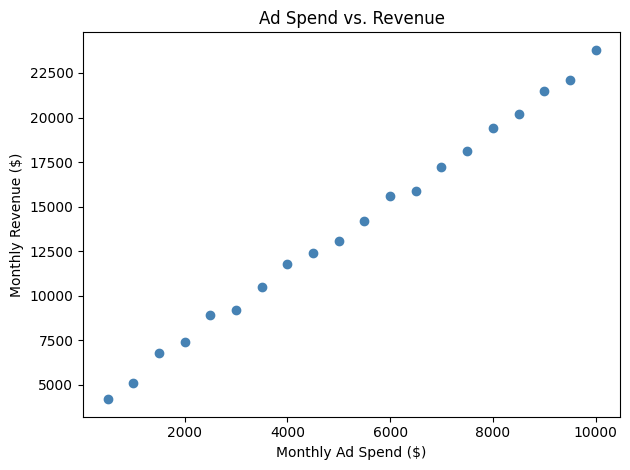

In [15]:
plt.scatter(
    X2,
    y2,
    color='steelblue',
    label='Actual Data'
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

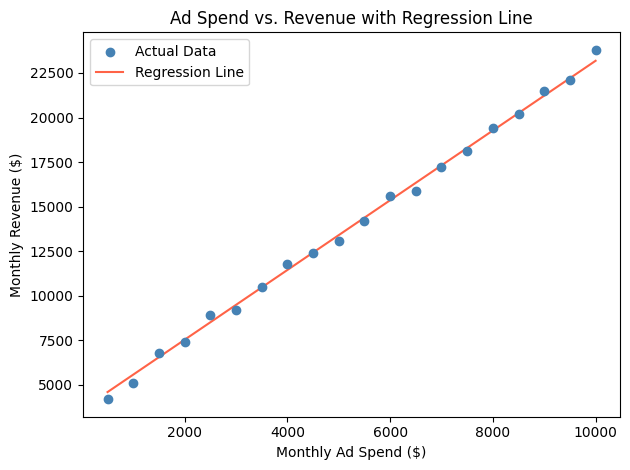

In [16]:
plt.scatter(
    X2,
    y2,
    color='steelblue',
    label='Actual Data',
    zorder=3
)

spend_range = pd.DataFrame({
    'monthly_ad_spend': np.linspace(
        X2['monthly_ad_spend'].min(),
        X2['monthly_ad_spend'].max(),
        100
    )
})

revenue_line = model2.predict(spend_range)

plt.plot(
    spend_range,
    revenue_line,
    color='tomato',
    label='Regression Line'
)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue with Regression Line')
plt.legend()
plt.tight_layout()
plt.show()

The regression line appears to fit the data very well because most of the points are close to the line. This matches the R² score, which showed that the model explains almost all of the variation in revenue. Overall, this confirms that monthly ad spend is a strong predictor of monthly revenue in this dataset.

## Bonus

In [17]:
X2_train_b, X2_test_b, y2_train_b, y2_test_b = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=10
)

model_bonus = LinearRegression()
model_bonus.fit(X2_train_b, y2_train_b)

bonus_r2 = model_bonus.score(X2_test_b, y2_test_b)

print(f"Bonus R² score with test_size=0.3 and random_state=10: {bonus_r2:.3f}")

Bonus R² score with test_size=0.3 and random_state=10: 0.998


When I changed the test size and random state, the R² score changed slightly because the model was trained and tested on a different split of the data. This shows that model evaluation can depend on how the data is split. However, the model still appears strong because the relationship between ad spend and revenue is very linear.

This exercise helped me understand the basic process of building a linear regression model. In Lab 1, I worked through a sample model that predicted exam scores based on hours studied. In Lab 2, I built my own model to predict monthly revenue from monthly ad spend. I learned how to define features and targets, split the data, train the model with fit(), make predictions with predict(), evaluate the model with R², and visualize the regression line. The main idea I learned is that linear regression helps explain and predict a numeric outcome when there is a relationship between two variables.